# Cálculo & Otimização para ML — versão **visual**

Cada conceito que a gente construiu, agora **desenhado**, na mesma ordem:
**derivada → regra da cadeia → gradiente → gradient descent → Lagrange.**

> A ideia central: a álgebra linear deu o *espaço*; o cálculo dá o *movimento* —
> como **descer a rampa de erro** até o fundo da tigela.

Rode célula por célula (Shift+Enter).


In [1]:
import numpy as np
import matplotlib.pyplot as plt
np.set_printoptions(precision=3, suppress=True)
print("Pronto. Rode as próximas células na ordem.")


Pronto. Rode as próximas células na ordem.


## 1) Derivada = inclinação (e zero = fundo do vale)
A derivada num ponto é a **inclinação da reta tangente** ali. No **fundo do vale**
a inclinação é **zero** — é o que a gente procura pra achar o menor erro.

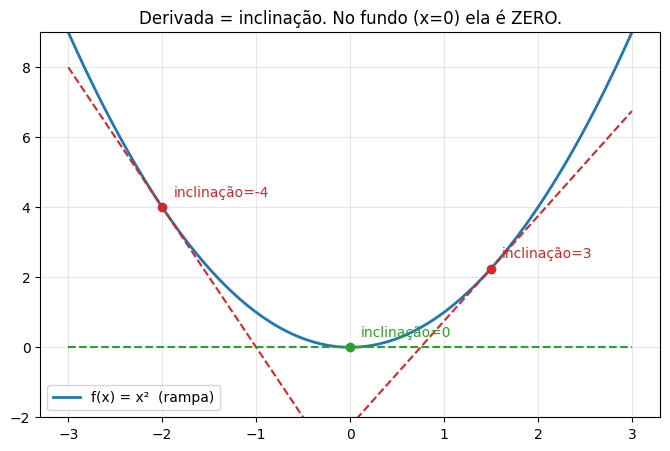

df(0) = 0 -> inclinação zero no mínimo (o gatilho pro ponto mais baixo)


In [2]:
f  = lambda x: x**2            # uma tigela simples
df = lambda x: 2*x             # derivada = inclinação

xs = np.linspace(-3, 3, 200)
pontos = [-2.0, 0.0, 1.5]      # onde desenhar a tangente

fig, ax = plt.subplots(figsize=(8,5))
ax.plot(xs, f(xs), color="C0", lw=2, label="f(x) = x²  (rampa)")
for p in pontos:
    tang = f(p) + df(p)*(xs - p)          # reta tangente: inclinação = df(p)
    cor = "C2" if abs(df(p))<1e-9 else "C3"
    ax.plot(xs, tang, "--", color=cor, lw=1.5)
    ax.plot(p, f(p), "o", color=cor)
    ax.annotate(f"inclinação={df(p):.0f}", (p, f(p)), textcoords="offset points",
                xytext=(8,8), color=cor)
ax.set_ylim(-2, 9); ax.set_title("Derivada = inclinação. No fundo (x=0) ela é ZERO.")
ax.legend(); ax.grid(alpha=.3); plt.show()
print("df(0) =", df(0), "-> inclinação zero no mínimo (o gatilho pro ponto mais baixo)")


## 2) Regra da cadeia = engrenagens (as taxas se multiplicam)
Se A gira B em 2× e B gira C em 3×, então A gira C em **2×3 = 6×**. Cada elo
**amplifica** o anterior — por isso as derivadas se **multiplicam** na cadeia.
É o motor do **backpropagation**.

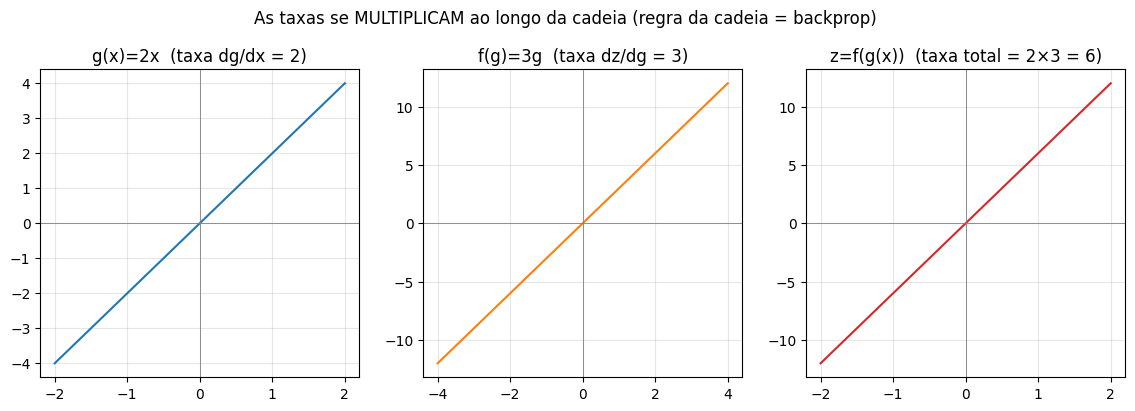

dz/dx (medido) = 6.0  == 2 × 3 = 6


In [3]:
# cadeia: z = f(g(x)), com g(x)=2x (taxa 2) e f(y)=3y (taxa 3) -> dz/dx = 6
x = np.linspace(-2, 2, 100)
g = 2*x        # 1ª engrenagem: taxa 2
z = 3*g        # 2ª engrenagem: taxa 3  -> z = 6x

fig, axes = plt.subplots(1, 3, figsize=(14,4))
axes[0].plot(x, g, "C0"); axes[0].set_title("g(x)=2x  (taxa dg/dx = 2)")
axes[1].plot(g, z, "C1"); axes[1].set_title("f(g)=3g  (taxa dz/dg = 3)")
axes[2].plot(x, z, "C3"); axes[2].set_title("z=f(g(x))  (taxa total = 2×3 = 6)")
for a in axes: a.grid(alpha=.3); a.axhline(0,color="gray",lw=.6); a.axvline(0,color="gray",lw=.6)
plt.suptitle("As taxas se MULTIPLICAM ao longo da cadeia (regra da cadeia = backprop)", y=1.03)
plt.show()
print("dz/dx (medido) =", np.gradient(z, x)[50].round(2), " == 2 × 3 = 6")


## 3) Gradiente = a bússola da subida mais íngreme
Numa paisagem de várias entradas, o gradiente é o **vetor** que aponta pra
**subida mais íngreme**; o oposto (−∇f) aponta pra **descida**. No mínimo, ele é o
**vetor zero**. As setas abaixo são o gradiente sobre as curvas de nível.

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 10178 (\N{PERPENDICULAR}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


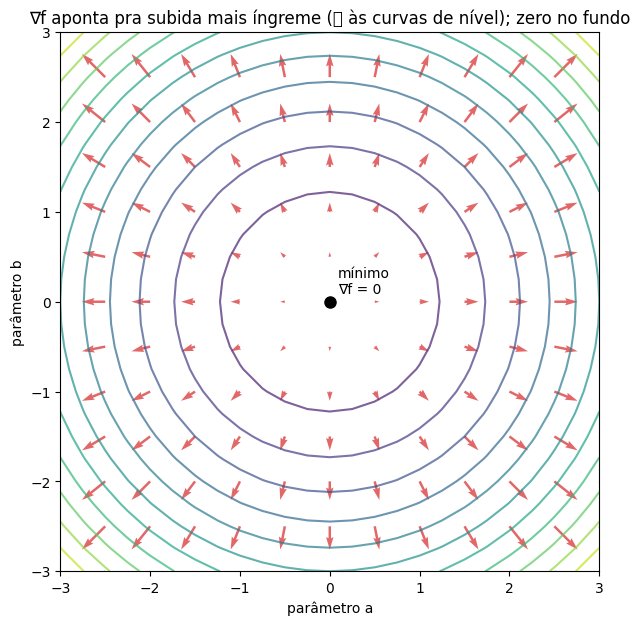

∇f no ponto (2,1) = (4, 2) -> aponta pra fora; −∇f desce pro centro


In [4]:
# f(a,b) = a² + b²  -> tigela; gradiente = (2a, 2b) aponta pra fora (subida)
A, B = np.meshgrid(np.linspace(-3,3,25), np.linspace(-3,3,25))
Z = A**2 + B**2
gA, gB = 2*A, 2*B          # gradiente

fig, ax = plt.subplots(figsize=(7,7))
cs = ax.contour(A, B, Z, levels=12, cmap="viridis", alpha=.7)   # curvas de nível
# setas do gradiente (subamostradas pra não poluir)
s = slice(None, None, 2)
ax.quiver(A[s,s], B[s,s], gA[s,s], gB[s,s], color="C3", alpha=.7)
ax.plot(0,0,"ko", ms=8); ax.annotate("mínimo\n∇f = 0", (0,0), xytext=(6,6),
        textcoords="offset points")
ax.set_title("∇f aponta pra subida mais íngreme (⟂ às curvas de nível); zero no fundo")
ax.set_xlabel("parâmetro a"); ax.set_ylabel("parâmetro b"); ax.set_aspect("equal")
plt.show()
print("∇f no ponto (2,1) =", (2*2, 2*1), "-> aponta pra fora; −∇f desce pro centro")


## 4) Gradient descent = descer a rampa no nevoeiro
Sem enxergar o fundo, você sente a inclinação e dá um passo em **−∇f**. Repetindo,
chega ao mínimo. O caminho abaixo é o algoritmo descendo a tigela passo a passo.

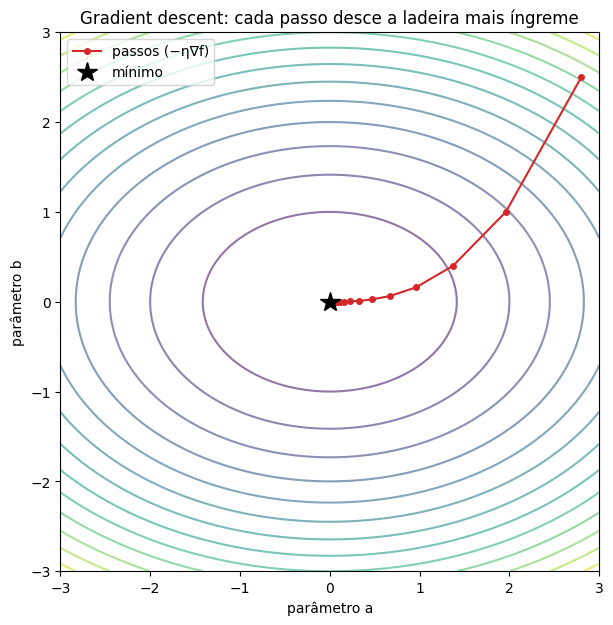

começou em [2.8 2.5] -> terminou em [0. 0.] (perto do mínimo)


In [5]:
f  = lambda a,b: a**2 + 2*b**2
grad = lambda a,b: np.array([2*a, 4*b])

p = np.array([2.8, 2.5])     # ponto inicial
eta = 0.15                   # learning rate (tamanho do passo)
caminho = [p.copy()]
for _ in range(25):
    p = p - eta*grad(*p)     # novo = atual − η·∇f
    caminho.append(p.copy())
caminho = np.array(caminho)

A,B = np.meshgrid(np.linspace(-3,3,100), np.linspace(-3,3,100))
fig, ax = plt.subplots(figsize=(7,7))
ax.contour(A,B, f(A,B), levels=15, cmap="viridis", alpha=.6)
ax.plot(caminho[:,0], caminho[:,1], "o-", color="C3", ms=4, lw=1.5, label="passos (−η∇f)")
ax.plot(0,0,"k*", ms=15, label="mínimo")
ax.set_title("Gradient descent: cada passo desce a ladeira mais íngreme")
ax.set_xlabel("parâmetro a"); ax.set_ylabel("parâmetro b")
ax.legend(); ax.set_aspect("equal"); plt.show()
print(f"começou em {caminho[0].round(2)} -> terminou em {caminho[-1].round(3)} (perto do mínimo)")


### 4b) O tamanho do passo (learning rate) importa
Passo pequeno: seguro, lento. Passo grande: rápido, mas pode **oscilar** ou
**divergir**. Veja três η no mesmo problema.

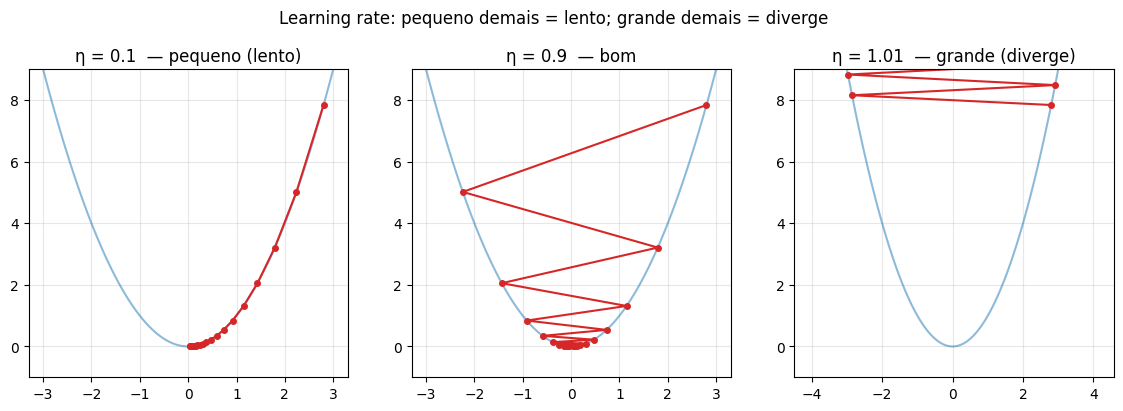

In [6]:
def descer(eta, n=20, start=2.8):
    x = start; hist=[x]
    for _ in range(n):
        x = x - eta*(2*x)     # min de x²
        hist.append(x)
    return hist

xs = np.linspace(-3,3,100)
fig, axes = plt.subplots(1,3, figsize=(14,4))
for ax,(eta,nome) in zip(axes, [(0.1,"pequeno (lento)"),(0.9,"bom"),(1.01,"grande (diverge)")]):
    h = descer(eta)
    ax.plot(xs, xs**2, "C0", alpha=.5)
    ax.plot(h, [x**2 for x in h], "o-", color="C3", ms=4)
    ax.set_title(f"η = {eta}  — {nome}"); ax.grid(alpha=.3); ax.set_ylim(-1,9)
plt.suptitle("Learning rate: pequeno demais = lento; grande demais = diverge", y=1.03)
plt.show()


## 5) SGD = passos ruidosos (mini-batch)
Usar um pedacinho aleatório dos dados por passo deixa o caminho **ruidoso**, mas
muito mais barato — e na prática funciona melhor em dados grandes.

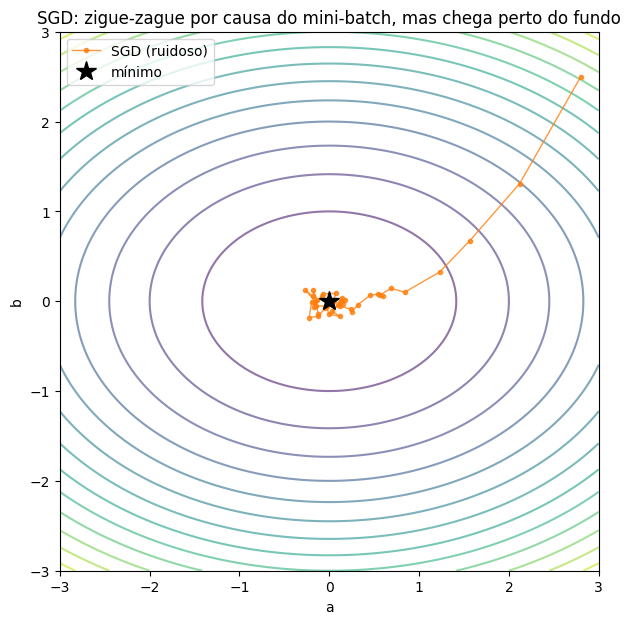

In [7]:
rng = np.random.default_rng(0)
f = lambda a,b: a**2 + 2*b**2
grad = lambda a,b: np.array([2*a, 4*b])

p = np.array([2.8, 2.5]); eta=0.12; caminho=[p.copy()]
for _ in range(40):
    ruido = rng.normal(0, 0.6, 2)          # simula o "batch" ruidoso
    p = p - eta*(grad(*p) + ruido)
    caminho.append(p.copy())
caminho=np.array(caminho)

A,B=np.meshgrid(np.linspace(-3,3,100),np.linspace(-3,3,100))
fig,ax=plt.subplots(figsize=(7,7))
ax.contour(A,B,f(A,B),levels=15,cmap="viridis",alpha=.6)
ax.plot(caminho[:,0],caminho[:,1],"o-",color="C1",ms=3,lw=1,alpha=.8,label="SGD (ruidoso)")
ax.plot(0,0,"k*",ms=15,label="mínimo")
ax.set_title("SGD: zigue-zague por causa do mini-batch, mas chega perto do fundo")
ax.set_xlabel("a"); ax.set_ylabel("b"); ax.legend(); ax.set_aspect("equal"); plt.show()


## 6) Lagrange = mínimo preso a uma trilha (tangência)
Você quer o ponto mais baixo do erro, mas **preso a uma restrição** (a linha preta).
O ótimo é onde a **curva de nível tangencia** a trilha — ali os gradientes ficam
**paralelos** (∇f = λ∇g). Base do SVM.

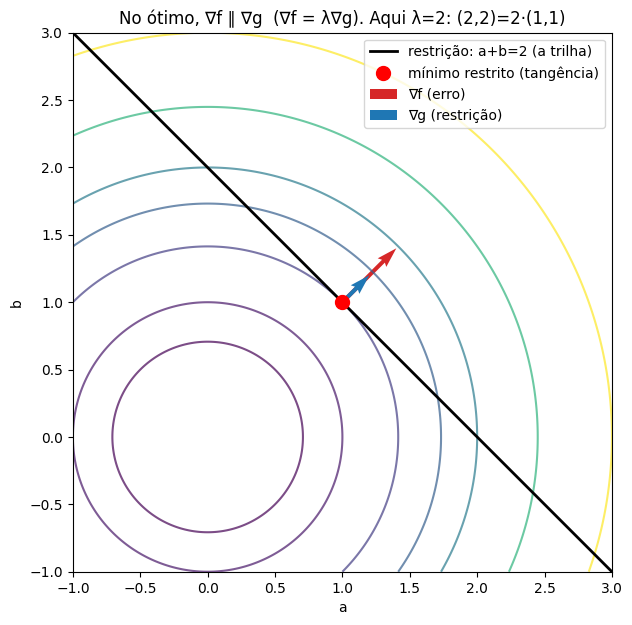

∇f = (2, 2)  ∇g = (1, 1)  -> paralelos, λ = 2


In [8]:
# erro: f(a,b)=a²+b² (tigela). restrição: a + b = 2 (uma reta = a trilha)
A,B = np.meshgrid(np.linspace(-1,3,300), np.linspace(-1,3,300))
F = A**2 + B**2

# ótimo restrito de a²+b² com a+b=2 é (1,1) (por simetria)
opt = np.array([1.0, 1.0])

fig, ax = plt.subplots(figsize=(7,7))
ax.contour(A,B,F, levels=[0.5,1,2,3,4,6,9], cmap="viridis", alpha=.7)
xs = np.linspace(-1,3,50)
ax.plot(xs, 2-xs, "k-", lw=2, label="restrição: a+b=2 (a trilha)")
ax.plot(*opt, "ro", ms=10, label="mínimo restrito (tangência)")
# gradientes no ótimo: ∇f=(2,2), ∇g=(1,1) -> paralelos!
ax.quiver(*opt, 2,2, color="C3", scale=20, label="∇f (erro)")
ax.quiver(*opt, 1,1, color="C0", scale=20, label="∇g (restrição)")
ax.set_title("No ótimo, ∇f ∥ ∇g  (∇f = λ∇g). Aqui λ=2: (2,2)=2·(1,1)")
ax.set_xlabel("a"); ax.set_ylabel("b"); ax.legend(loc="upper right"); ax.set_aspect("equal")
plt.show()
print("∇f =", (2,2), " ∇g =", (1,1), " -> paralelos, λ = 2")


## Fio condutor
**derivada** (inclinação) → **regra da cadeia** (backprop) → **gradiente** (a bússola)
→ **gradient descent** (descer a rampa) → **Lagrange** (descer preso à trilha).
E o gradiente zero da rampa de erro é, nos mínimos quadrados, o `XᵀX ŵ = Xᵀb` que
você projetou — cálculo e álgebra linear, o mesmo motor.